1. Content analysis: Analyze the content of social media data  to determine what topics are being given data set  using topic modelling, keyword extractor

In [17]:
import pandas as pd
import nltk
import gensim
from gensim import corpora
from gensim.models import LdaModel
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from collections import Counter
import matplotlib.pyplot as plt

In [18]:
nltk.download('stopwords')
nltk.download('wordnet')

[nltk_data] Downloading package stopwords to C:\Users\Om
[nltk_data]     Shete\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to C:\Users\Om
[nltk_data]     Shete\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


True

In [19]:
df = pd.read_csv('CSV/location.csv')
df.head()

,Unnamed: 0.1,Unnamed: 0,Text,Sentiment,Timestamp,User,Platform,Hashtags,Retweets,Likes,Country,Year,Month,Day,Hour
0,0,0,Enjoying a beautiful day at the park! ...,Positive,2023-01-15 12:30:00,User123,Twitter,#Nature #Park,15.0,30.0,USA,2023,1,15,12
1,1,1,Traffic was terrible this morning. ...,Negative,2023-01-15 08:45:00,CommuterX,Twitter,#Traffic #Morning,5.0,10.0,Canada,2023,1,15,8
2,2,2,Just finished an amazing workout! 💪 ...,Positive,2023-01-15 15:45:00,FitnessFan,Instagram,#Fitness #Workout,20.0,40.0,USA,2023,1,15,15
3,3,3,Excited about the upcoming weekend getaway! ...,Positive,2023-01-15 18:20:00,AdventureX,Facebook,#Travel #Adventure,8.0,15.0,UK,2023,1,15,18
4,4,4,Trying out a new recipe for dinner tonight. ...,Neutral,2023-01-15 19:55:00,ChefCook,Instagram,#Cooking #Food,12.0,25.0,Australia,2023,1,15,19


In [20]:
stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

print(stop_words)

{'at', "mightn't", 'its', 'where', 'some', 'me', 'he', "i've", "he's", 'needn', 'this', 'did', 'other', 'am', "he'd", 're', 'any', "you've", 'myself', 'hasn', 'hers', 'doing', "i'm", 'didn', 'but', 'most', 'been', 'having', 'to', 'o', 'because', 'such', 'isn', 'her', "i'd", 'during', 'ourselves', 'under', 'mightn', "won't", 'you', 'yourselves', 'my', 'all', 've', 'for', 'is', 'yours', "that'll", 'very', 'are', "they've", 'which', 'an', 'shouldn', 'it', 'so', 'when', 'does', 'himself', 'ours', 'then', "mustn't", 'our', 'wouldn', 'do', 'how', 'your', 'we', 'being', 'once', "it'd", 'while', 'again', 'they', "we're", 'won', 'what', 'same', 'has', 'of', 'have', 'own', 'no', "couldn't", "it'll", 'nor', 'itself', 'only', 'here', 'in', "i'll", 'i', 'him', "needn't", 's', 'doesn', "wouldn't", 'herself', 'into', 'that', 'those', 'will', 'had', 'not', "shan't", 'these', 'shan', 'through', 'few', 'or', 'below', "they'll", "you'd", 'his', 'out', 'ma', 'before', "didn't", 'off', 'll', 'yourself', 'a

In [21]:
def pre_process(text):
    tokens = text.lower().split()
    lemma = [ lemmatizer.lemmatize(token) for token in tokens if token not in stop_words ]
    return lemma

In [22]:
df['tokens'] = df['Text'].apply(pre_process)
print(df.head())

   Unnamed: 0.1  Unnamed: 0  ... Hour                                   tokens
0             0           0  ...   12        [enjoying, beautiful, day, park!]
1             1           1  ...    8            [traffic, terrible, morning.]
2             2           2  ...   15         [finished, amazing, workout!, 💪]
3             3           3  ...   18   [excited, upcoming, weekend, getaway!]
4             4           4  ...   19  [trying, new, recipe, dinner, tonight.]

[5 rows x 16 columns]


In [23]:
dictionary = corpora.Dictionary(df['tokens'])
print(dictionary)
corpus = [ dictionary.doc2bow(token) for token in df['tokens']]
print(corpus)

Dictionary<2934 unique tokens: ['beautiful', 'day', 'enjoying', 'park!', 'morning.']...>
[[(0, 1), (1, 1), (2, 1), (3, 1)], [(4, 1), (5, 1), (6, 1)], [(7, 1), (8, 1), (9, 1), (10, 1)], [(11, 1), (12, 1), (13, 1), (14, 1)], [(15, 1), (16, 1), (17, 1), (18, 1), (19, 1)], [(20, 1), (21, 1), (22, 1), (23, 1), (24, 1)], [(1, 1), (25, 1), (26, 1), (27, 1), (28, 1), (29, 1), (30, 1)], [(16, 1), (31, 1), (32, 1), (33, 1)], [(34, 1), (35, 1), (36, 1), (37, 1)], [(38, 1), (39, 1), (40, 1), (41, 1), (42, 1)], [(16, 1), (43, 1), (44, 1), (45, 1), (46, 1), (47, 1)], [(20, 1), (48, 1), (49, 1), (50, 1)], [(51, 1), (52, 1), (53, 1), (54, 1)], [(10, 1), (16, 2), (55, 1), (56, 1), (57, 1)], [(58, 1), (59, 1), (60, 1), (61, 1)], [(62, 1), (63, 1), (64, 1), (65, 1)], [(66, 1), (67, 1), (68, 1), (69, 1), (70, 1)], [(71, 1), (72, 1), (73, 1), (74, 1)], [(75, 1), (76, 1), (77, 1), (78, 1)], [(20, 1), (79, 1), (80, 1), (81, 1), (82, 1)], [(2, 1), (83, 1), (84, 1), (85, 1), (86, 1)], [(52, 1), (78, 1), (87, 1

In [24]:
# LDA TO MODEL TOPIC Modelling
num_topics = 5
ldamodel = LdaModel(num_topics=num_topics, corpus=corpus, id2word=dictionary, passes=20)

In [25]:
print('Topics')
for topic_id in ldamodel.print_topics():
    print(f"Topic {topic_id}")

Topics
Topic (0, '0.005*"new" + 0.004*"laughter" + 0.004*"dance" + 0.004*"journey" + 0.004*"serene" + 0.003*"old" + 0.003*"serenity" + 0.003*"caught" + 0.003*"joy" + 0.003*"whisper"')
Topic (1, '0.010*"like" + 0.006*"shattered" + 0.005*"feeling" + 0.004*"sense" + 0.003*"dancing" + 0.003*"echo" + 0.003*"dream" + 0.003*"night." + 0.003*"filled" + 0.003*"soaring"')
Topic (2, '0.006*"finding" + 0.004*"surprise" + 0.004*"art" + 0.004*"embracing" + 0.004*"laughter" + 0.004*"exploring" + 0.004*"seed" + 0.004*"feeling" + 0.003*"acceptance" + 0.003*"creating"')
Topic (3, '0.011*"new" + 0.005*"lost" + 0.005*"every" + 0.005*"challenging" + 0.004*"excitement" + 0.004*"life\'s" + 0.004*"day" + 0.004*"echo" + 0.004*"upcoming" + 0.003*"world"')
Topic (4, '0.005*"new" + 0.005*"moment" + 0.005*"exploring" + 0.004*"hopeful" + 0.004*"whisper" + 0.003*"embracing" + 0.003*"joy" + 0.003*"beauty" + 0.003*"lost" + 0.003*"echo"')


In [26]:
all_tokens = [token for tokens in df['tokens'] for token in tokens]
keyword_ctr = Counter(all_tokens)

print(keyword_ctr)

Counter({'new': 43, 'like': 27, 'feeling': 26, 'moment': 21, 'beauty': 20, 'echo': 20, 'laughter': 19, 'every': 19, 'day': 18, 'exploring': 17, 'art': 17, 'lost': 17, 'whisper': 17, 'dream': 17, 'joy': 16, 'journey': 16, 'symphony': 16, 'personal': 15, 'sense': 15, "life's": 15, 'dance': 15, 'heart': 15, 'garden': 14, 'shattered': 14, 'challenging': 13, 'surprise': 13, 'old': 13, 'embracing': 13, 'serenity': 13, 'world': 12, 'challenge': 12, 'finding': 12, 'excitement': 12, 'hopeful': 12, 'tale': 12, 'creating': 12, 'ancient': 12, 'concert,': 12, 'tear': 11, 'upcoming': 10, 'quiet': 10, 'love': 10, 'friend': 10, 'night': 10, 'gratitude': 10, 'silent': 10, 'emotion': 10, 'sky': 10, 'school': 10, 'reflecting': 9, 'attending': 9, 'learning': 9, 'painting': 9, 'local': 9, 'family': 9, 'experiencing': 9, 'warmth': 9, 'life': 9, 'embarking': 9, 'wave': 9, 'time.': 9, 'labyrinth': 9, 'dancing': 9, 'soul': 9, 'winter': 8, 'cup': 8, 'project': 8, 'music': 8, 'nature': 8, 'kindness': 8, 'serene'

In [27]:
for keyword, ctr in keyword_ctr.most_common(10):
    print(f"{keyword}: {ctr}")

new: 43
like: 27
feeling: 26
moment: 21
beauty: 20
echo: 20
laughter: 19
every: 19
day: 18
exploring: 17


In [28]:
for idx in range(num_topics):
    topic_info = ldamodel.print_topic(idx, topn=10)
    word_and_weights = topic_info.split(" + ")
    print(word_and_weights)

    for item in word_and_weights:
        weight, word = item.split('*')
        print(f" - {word.strip()} (Weight: {weight.strip()})")

['0.005*"new"', '0.004*"laughter"', '0.004*"dance"', '0.004*"journey"', '0.004*"serene"', '0.003*"old"', '0.003*"serenity"', '0.003*"caught"', '0.003*"joy"', '0.003*"whisper"']
 - "new" (Weight: 0.005)
 - "laughter" (Weight: 0.004)
 - "dance" (Weight: 0.004)
 - "journey" (Weight: 0.004)
 - "serene" (Weight: 0.004)
 - "old" (Weight: 0.003)
 - "serenity" (Weight: 0.003)
 - "caught" (Weight: 0.003)
 - "joy" (Weight: 0.003)
 - "whisper" (Weight: 0.003)
['0.010*"like"', '0.006*"shattered"', '0.005*"feeling"', '0.004*"sense"', '0.003*"dancing"', '0.003*"echo"', '0.003*"dream"', '0.003*"night."', '0.003*"filled"', '0.003*"soaring"']
 - "like" (Weight: 0.010)
 - "shattered" (Weight: 0.006)
 - "feeling" (Weight: 0.005)
 - "sense" (Weight: 0.004)
 - "dancing" (Weight: 0.003)
 - "echo" (Weight: 0.003)
 - "dream" (Weight: 0.003)
 - "night." (Weight: 0.003)
 - "filled" (Weight: 0.003)
 - "soaring" (Weight: 0.003)
['0.006*"finding"', '0.004*"surprise"', '0.004*"art"', '0.004*"embracing"', '0.004*"la

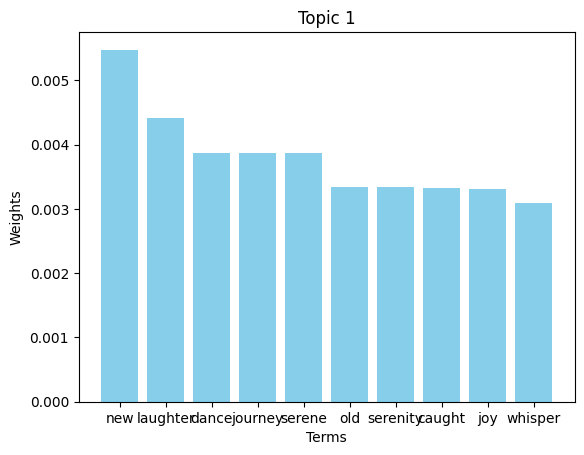

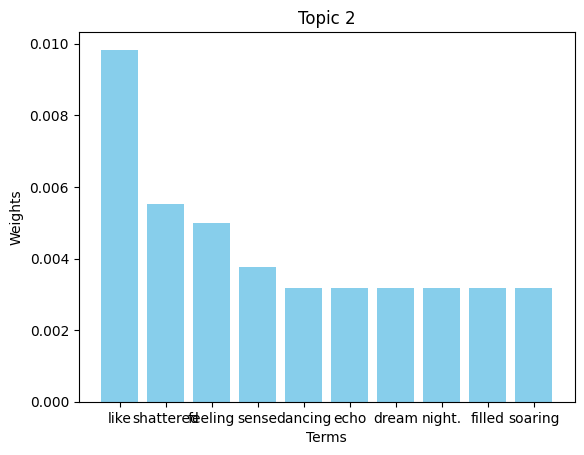

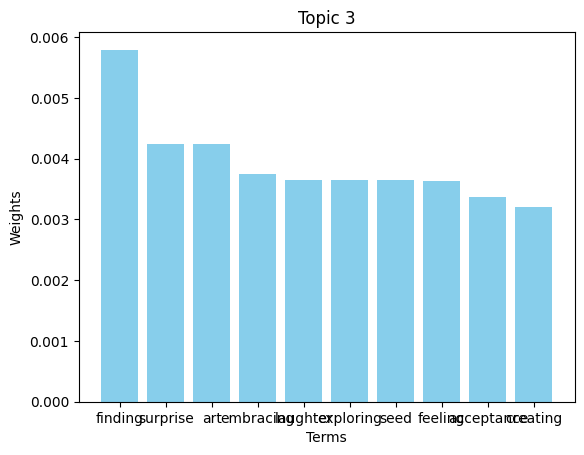

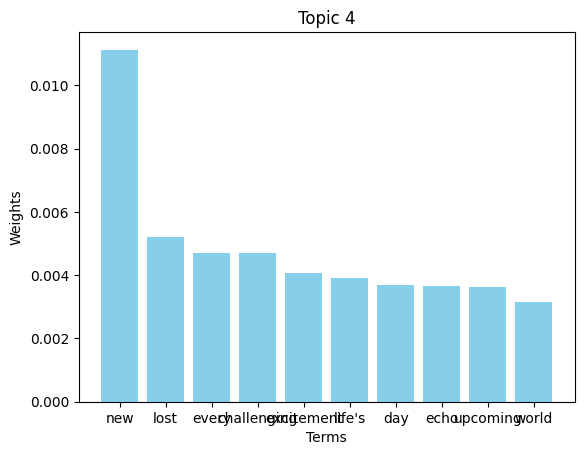

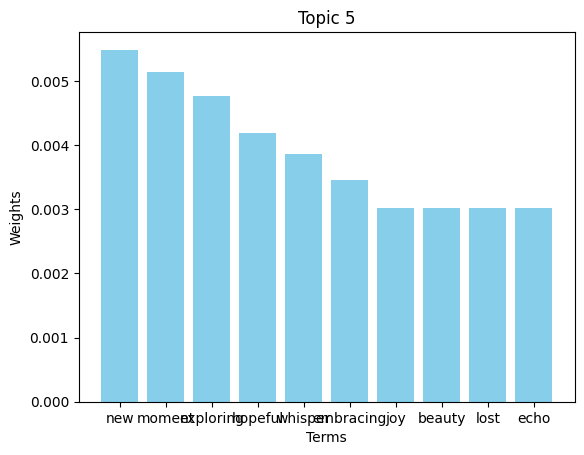

In [29]:
for idx, topic in enumerate(ldamodel.show_topics(num_topics, formatted=False)):
    topic_term = [term[0] for term in topic[1]]
    term_weight = [term[1] for term in topic[1]]

    plt.figure()
    plt.bar(topic_term, term_weight, color='skyblue')
    plt.title(f"Topic {idx + 1}")
    plt.xlabel("Terms")
    plt.ylabel("Weights")
    plt.show()